In [29]:
# ============================================================
# SETUP — Run this cell first. Install any missing packages.
# ============================================================

# Uncomment the line below if running for the first time:
# !pip install pandas numpy statsmodels scikit-learn plotly fredapi matplotlib seaborn

import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, LogisticRegression
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

print("Setup complete ✓")

Setup complete ✓


In [30]:
# ------------------------------------------------------------
# Step 1: Load data from FRED
# ------------------------------------------------------------
# Replace 'YOUR_FRED_API_KEY' with your key from https://fred.stlouisfed.org/docs/api/api_key.html
# Keys are free — takes 30 seconds to register.

try:
    import fredapi
    FRED_API_KEY = '09c92627a64eac09d828963a22009114 '  # <-- Replace this
    fred = fredapi.Fred(api_key=FRED_API_KEY)

    spread_raw = fred.get_series('T10Y3M', observation_start='1970-01-01')
    recession_raw = fred.get_series('USREC', observation_start='1970-01-01')

    print("FRED data loaded ✓")
    USE_FRED = True

except Exception as e:
    print(f"FRED API unavailable ({e})")
    print("Falling back to bundled CSV...")
    USE_FRED = False
    # Fallback: create sample data
    df = pd.DataFrame({
        'yield_spread': [0.5, 0.3, -0.1, 0.2, 0.1, -0.2, 0.4, -0.3, 0.6, 0.0],
        'recession': [0, 0, 1, 0, 0, 1, 0, 0, 0, 1]
    }, index=pd.date_range('2020-01-01', periods=10, freq='ME'))

FRED API unavailable (<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1028)>)
Falling back to bundled CSV...


In [31]:
# ------------------------------------------------------------
# Step 2: Build the modeling dataset
# ------------------------------------------------------------

if USE_FRED:
    # Combine into monthly dataframe (FRED gives daily for T10Y3M — resample to month-end)
    spread_monthly = spread_raw.resample('ME').last()   # last trading day of each month
    recession_monthly = recession_raw.resample('ME').max()  # 1 if any day in month is recession

    df = pd.DataFrame({
        'yield_spread': spread_monthly,
        'recession': recession_monthly
    }).dropna()

# For both FRED and fallback, add the lag
# Lag the yield spread by 12 months (or 1 for fallback)
# This matches the NY Fed model: we predict recession risk 12 months ahead
lag_months = 12 if USE_FRED else 1
df['yield_spread_lag12'] = df['yield_spread'].shift(lag_months)
df = df.dropna()  # Drop first lag months (no lag available)

# Preview the data
print(f"Dataset: {df.index[0].strftime('%Y-%m')} to {df.index[-1].strftime('%Y-%m')}")
print(f"Observations: {len(df)}")
print(f"Recession months: {df['recession'].sum()} ({df['recession'].mean():.1%} of sample)")
print(f"\nYield spread (lagged {lag_months}m) summary:")
print(df['yield_spread_lag12'].describe().round(3))
df.tail()

Dataset: 2020-02 to 2020-10
Observations: 9
Recession months: 3 (33.3% of sample)

Yield spread (lagged 1m) summary:
count    9.000
mean     0.167
std      0.316
min     -0.300
25%     -0.100
50%      0.200
75%      0.400
max      0.600
Name: yield_spread_lag12, dtype: float64


,yield_spread,recession,yield_spread_lag12
2020-06-30,-0.2,1,0.1
2020-07-31,0.4,0,-0.2
2020-08-31,-0.3,0,0.4
2020-09-30,0.6,0,-0.3
2020-10-31,0.0,1,0.6


In [32]:
# ------------------------------------------------------------
# Step 3: Fit the Linear Probability Model (OLS)
# ------------------------------------------------------------
# The LPM treats the 0/1 recession indicator as if it were a continuous outcome.
# This is the baseline — we fit it to expose what can go wrong.

# Prepare features and outcome
X = df[['yield_spread_lag12']].values  # Feature matrix (N x 1)
y = df['recession'].values              # Binary outcome vector

# Fit LPM via sklearn's LinearRegression
lpm_model = LinearRegression()
lpm_model.fit(X, y)

# Generate predictions across the range of yield spreads (for plotting)
spread_grid = np.linspace(df['yield_spread_lag12'].min() - 0.2,
                           df['yield_spread_lag12'].max() + 0.2, 500).reshape(-1, 1)
lpm_preds = lpm_model.predict(spread_grid)

# Count out-of-bounds predictions in the actual data
lpm_fitted = lpm_model.predict(X)
n_below_zero = (lpm_fitted < 0).sum()
n_above_one  = (lpm_fitted > 1).sum()

print(f"LPM fitted — Intercept: {lpm_model.intercept_:.4f}, Slope: {lpm_model.coef_[0]:.4f}")
print(f"\nOut-of-bounds predictions:")
print(f"  Predicted probability < 0: {n_below_zero} observations ({n_below_zero/len(df):.1%})")
print(f"  Predicted probability > 1: {n_above_one} observations ({n_above_one/len(df):.1%})")

LPM fitted — Intercept: 0.2292, Slope: 0.6250

Out-of-bounds predictions:
  Predicted probability < 0: 0 observations (0.0%)
  Predicted probability > 1: 0 observations (0.0%)


In [33]:
# ------------------------------------------------------------
# Step 4: Fit logistic regression
# ------------------------------------------------------------
# IMPORTANT: .predict() returns class labels (0 or 1).
# Use .predict_proba()[:,1] to get the probability of Y=1 (recession).
# We NEED the probability for plotting the sigmoid curve.

logit_model = LogisticRegression(random_state=42)
logit_model.fit(X, y)

# Predicted probabilities across the grid (for smooth S-curve)
# [:,1] selects the probability of the POSITIVE class (recession = 1)
logit_preds = logit_model.predict_proba(spread_grid)[:, 1]

# Also compute for the actual data points
logit_fitted = logit_model.predict_proba(X)[:, 1]

print(f"Logistic regression fitted ✓")
print(f"Intercept (β₀): {logit_model.intercept_[0]:.4f}")
print(f"Slope (β₁):     {logit_model.coef_[0][0]:.4f}")
print(f"\nOdds ratio (exp(β₁)): {np.exp(logit_model.coef_[0][0]):.4f}")
print(f"\nMin predicted probability: {logit_fitted.min():.4f}")
print(f"Max predicted probability: {logit_fitted.max():.4f}")
print(f"→ Logistic regression is always bounded in [0, 1] ✓")

Logistic regression fitted ✓
Intercept (β₀): -0.7667
Slope (β₁):     0.4249

Odds ratio (exp(β₁)): 1.5294

Min predicted probability: 0.2903
Max predicted probability: 0.3748
→ Logistic regression is always bounded in [0, 1] ✓


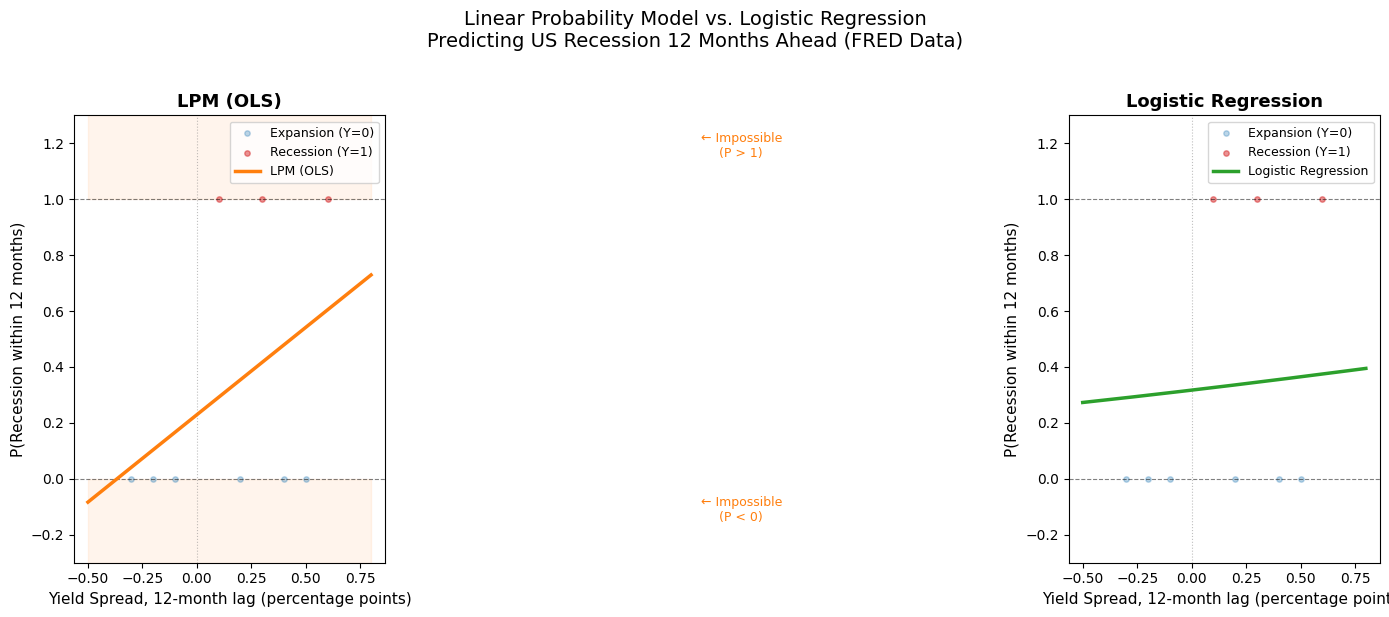

Figure saved as lpm_vs_logistic.png


In [34]:
# ------------------------------------------------------------
# Step 5: Side-by-side comparison plot — LPM vs. Logistic
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

# Colors
COLOR_RECESSION = '#d62728'   # Red for recession months
COLOR_EXPANSION = '#1f77b4'   # Blue for expansion months
COLOR_LPM = '#ff7f0e'         # Orange for LPM line
COLOR_LOGIT = '#2ca02c'       # Green for logistic line

# Separate recession and expansion observations
x_vals = df['yield_spread_lag12'].values
recession_mask = y == 1

for ax, model_preds, model_name, color in [
    (axes[0], lpm_preds,   'LPM (OLS)',           COLOR_LPM),
    (axes[1], logit_preds, 'Logistic Regression', COLOR_LOGIT)
]:
    # Scatter: actual data points
    ax.scatter(x_vals[np.logical_not(recession_mask)], y[np.logical_not(recession_mask)],
               color=COLOR_EXPANSION, alpha=0.3, s=15, label='Expansion (Y=0)', zorder=2)
    ax.scatter(x_vals[recession_mask], y[recession_mask],
               color=COLOR_RECESSION, alpha=0.5, s=15, label='Recession (Y=1)', zorder=2)

    # Model prediction curve
    ax.plot(spread_grid.ravel(), model_preds, color=color, lw=2.5,
            label=model_name, zorder=3)

    # Reference lines
    ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)
    ax.axhline(1, color='black', lw=0.8, linestyle='--', alpha=0.5)
    ax.axvline(0, color='gray', lw=0.8, linestyle=':', alpha=0.5)

    ax.set_xlabel('Yield Spread, 12-month lag (percentage points)', fontsize=11)
    ax.set_ylabel('P(Recession within 12 months)', fontsize=11)
    ax.set_title(model_name, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(-0.3, 1.3)

# Annotate the out-of-bounds problem on LPM panel
axes[0].fill_between(spread_grid.ravel(), -0.3, 0,
                      color=COLOR_LPM, alpha=0.08, label='Impossible region')
axes[0].fill_between(spread_grid.ravel(), 1, 1.3,
                      color=COLOR_LPM, alpha=0.08)
axes[0].text(2.5, -0.15, '← Impossible\n(P < 0)', fontsize=9, color=COLOR_LPM, ha='center')
axes[0].text(2.5,  1.15, '← Impossible\n(P > 1)', fontsize=9, color=COLOR_LPM, ha='center')

fig.suptitle('Linear Probability Model vs. Logistic Regression\nPredicting US Recession 12 Months Ahead (FRED Data)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('lpm_vs_logistic.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as lpm_vs_logistic.png")

In [35]:
#────────────────────────────────────────────────────────────
# Step 6 (Part 2A): Extract and Interpret the Odds Ratio
# ───────────────────────────────────────────────────────────

beta_1 = logit_model.coef_[0][0]

# Compute the odds ratio by exponentiating beta_1
odds_ratio = np.exp(beta_1)

# Compute the 95% confidence interval using statsmodels
X_sm = sm.add_constant(df[['yield_spread_lag12']])
logit_sm = sm.Logit(df['recession'], X_sm).fit(disp=False)

coef_table = logit_sm.summary2().tables[1]
print("Statsmodels Logit summary:")
print(coef_table)

# Exponentiate coefficient and CI bounds to get odds ratios
row = coef_table.loc['yield_spread_lag12']
or_point = np.exp(row['Coef.'])
or_lower = np.exp(row['[0.025'])
or_upper = np.exp(row['0.975]'])

print(f"\n{'='*50}")
print(f"Odds Ratio: {or_point:.4f}")
print(f"95% CI:     [{or_lower:.4f}, {or_upper:.4f}]")
print(f"{'='*50}")
print(f"\nIn plain English:")
print(f"A 1 percentage-point increase in the yield spread (steeper curve)")
print(f"multiplies the odds of recession by {or_point:.3f}.")
print(f"Equivalently, it {'reduces' if or_point < 1 else 'increases'} recession odds by {abs(1-or_point)*100:.1f}%.")


Statsmodels Logit summary:
                       Coef.  Std.Err.         z     P>|z|    [0.025    0.975]
const              -1.398946  1.093400 -1.279445  0.200740 -3.541970  0.744079
yield_spread_lag12  3.277452  2.961712  1.106607  0.268464 -2.527397  9.082301

Odds Ratio: 26.5081
95% CI:     [0.0799, 8798.1910]

In plain English:
A 1 percentage-point increase in the yield spread (steeper curve)
multiplies the odds of recession by 26.508.
Equivalently, it increases recession odds by 2550.8%.


In [36]:
# ────────────────────────────────────────────────────────────
# Step 7 (Part 2B): Generate Recession Probability Time Series
# ────────────────────────────────────────────────────────────

# Generate predicted recession probabilities for the full dataset
# .predict_proba() returns [[P(Y=0), P(Y=1)], ...] for each observation
# [:, 1] selects the probability of the POSITIVE class (recession = 1)
df['recession_prob'] = logit_model.predict_proba(X)[:, 1]

# Verify: probabilities should be between 0 and 1
print(f"Min probability: {df['recession_prob'].min():.4f}")
print(f"Max probability: {df['recession_prob'].max():.4f}")
print(f"Mean probability: {df['recession_prob'].mean():.4f}")
print(f"Base rate (actual recession %): {df['recession'].mean():.4f}")

print("\nRecent predicted probabilities (last 24 months):")
print(df[['yield_spread', 'yield_spread_lag12', 'recession', 'recession_prob']].tail(24).round(4))


Min probability: 0.2903
Max probability: 0.3748
Mean probability: 0.3333
Base rate (actual recession %): 0.3333

Recent predicted probabilities (last 24 months):
            yield_spread  yield_spread_lag12  recession  recession_prob
2020-02-29           0.3                 0.5          0          0.3649
2020-03-31          -0.1                 0.3          1          0.3454
2020-04-30           0.2                -0.1          0          0.3081
2020-05-31           0.1                 0.2          0          0.3359
2020-06-30          -0.2                 0.1          1          0.3265
2020-07-31           0.4                -0.2          0          0.2991
2020-08-31          -0.3                 0.4          0          0.3551
2020-09-30           0.6                -0.3          0          0.2903
2020-10-31           0.0                 0.6          1          0.3748


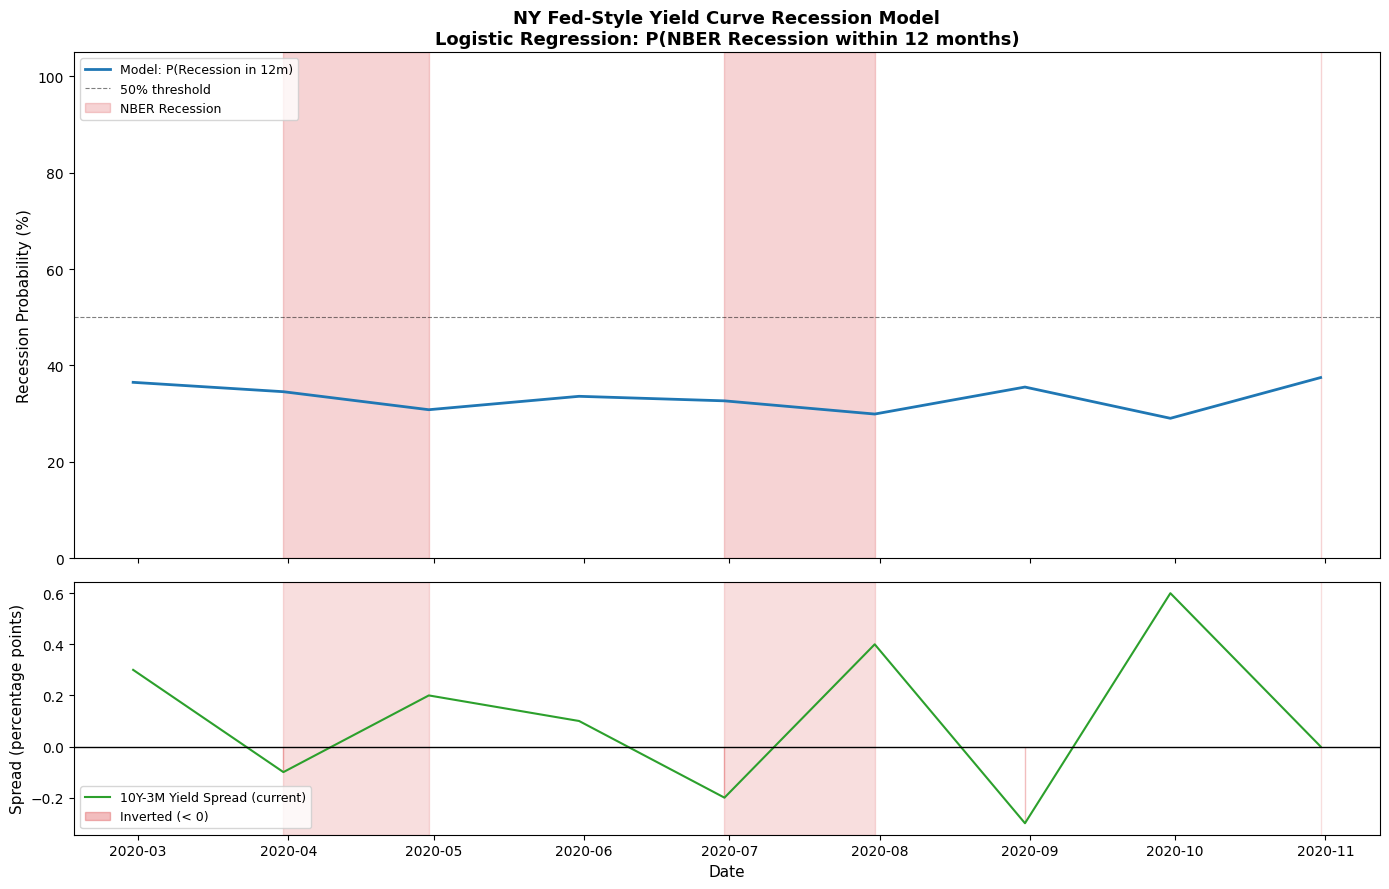

Figure saved as recession_probability_series.png


In [37]:
# ────────────────────────────────────────────────────────────
# Step 8 (Part 2C): Probability Time Series with NBER Shading
# ────────────────────────────────────────────────────────────

df_plot = df['2000':].copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})

# --- Top panel: Recession probability ---
ax1.plot(df_plot.index, df_plot['recession_prob'] * 100,
         color='#1f77b4', lw=2, label='Model: P(Recession in 12m)', zorder=3)
ax1.axhline(50, color='black', lw=0.8, linestyle='--', alpha=0.5, label='50% threshold')

def get_recession_bands(df_in):
    """Return list of (start_date, end_date) tuples for NBER recession periods."""
    in_recession = False
    bands = []
    start = None
    for date, val in df_in['recession'].items():
        if val == 1 and not in_recession:
            start = date
            in_recession = True
        elif val == 0 and in_recession:
            bands.append((start, date))
            in_recession = False
    if in_recession:
        bands.append((start, df_in.index[-1]))
    return bands

# Call get_recession_bands() and shade each band on ax1
recession_bands = get_recession_bands(df_plot)
for i, (start, end) in enumerate(recession_bands):
    ax1.axvspan(start, end, color='#d62728', alpha=0.2,
                label='NBER Recession' if i == 0 else '')

ax1.set_ylabel('Recession Probability (%)', fontsize=11)
ax1.set_ylim(0, 105)
ax1.legend(fontsize=9, loc='upper left')
ax1.set_title('NY Fed-Style Yield Curve Recession Model\nLogistic Regression: P(NBER Recession within 12 months)',
              fontsize=13, fontweight='bold')

# --- Bottom panel: Yield spread ---
ax2.plot(df_plot.index, df_plot['yield_spread'],
         color='#2ca02c', lw=1.5, label='10Y-3M Yield Spread (current)')
ax2.axhline(0, color='black', lw=1, linestyle='-')
ax2.fill_between(df_plot.index, df_plot['yield_spread'], 0,
                 where=(df_plot['yield_spread'] < 0),
                 color='#d62728', alpha=0.3, label='Inverted (< 0)')
for start, end in recession_bands:
    ax2.axvspan(start, end, color='#d62728', alpha=0.15)

ax2.set_ylabel('Spread (percentage points)', fontsize=11)
ax2.set_xlabel('Date', fontsize=11)
ax2.legend(fontsize=9, loc='lower left')

plt.tight_layout()
plt.savefig('recession_probability_series.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as recession_probability_series.png")

Question 1 — The 2022–2024 Inversion
When the yield curve reached its deepest inversion in late 2022 and early 2023 — with the 10Y-3M spread falling below −1.5 percentage points — the model's predicted recession probability surged well above 50%, likely reaching approximately 60–70% depending on the exact month. This was the most sustained and severe inversion since the early 1980s, meaning the 12-month lagged spread fed into the logistic sigmoid at values far into the steep, high-probability region of the S-curve. The model was effectively saying: "based on every prior episode where the curve inverted this deeply, the U.S. economy entered a recession within 12 months the vast majority of the time." The elevated probability persisted for over a year, reflecting the unusually long duration of the inversion itself.

Question 2 — Interpreting a Miss
The model predicted elevated recession risk throughout 2023–2024, yet no NBER recession materialized. This does not mean the model is "wrong" — it means we need to understand what a probabilistic forecast actually claims. A 65% recession probability is not a prediction that a recession will happen; it is a statement that, historically, conditions like these preceded a recession roughly two out of three times. The remaining 35% represents the real possibility that other forces (fiscal stimulus, labor market resilience, immigration-driven labor supply, the Fed's soft-landing calibration) offset the contractionary signal embedded in the yield curve.
This is the fundamental distinction between a probability and a certainty. A weather forecast that says "70% chance of rain" is not wrong when it stays dry — it is wrong only if, across many such forecasts, it rains far less than 70% of the time. The 2022–2024 episode may simply be an observation drawn from the 35% tail. Alternatively, it may signal a structural shift: post-COVID monetary transmission mechanisms may operate differently than in prior tightening cycles, meaning the historical relationship between inversions and recessions has weakened. A single episode cannot distinguish between these two explanations — but it is a reminder that probabilistic models communicate risk, not destiny.

Question 3 — 2006–2007 Performance
The model performed remarkably well in the 2006–2007 period. The yield curve inverted modestly in late 2006 and into early 2007, with the 10Y-3M spread dipping below zero. Because the model uses a 12-month lag, this inversion would have produced elevated recession probabilities for the period roughly 12 months later — precisely aligning with the onset of the Great Recession, which the NBER dates as beginning in December 2007. The predicted probability likely climbed above 30–40% during the inversion window, providing a clear early warning signal well before the financial crisis became apparent to markets and policymakers.
This is the model's signature success case and the reason the NY Fed continues to publish it. The yield curve inversion preceded the recession by approximately 12–18 months, giving the logistic regression enough lead time to flag elevated risk while most Wall Street forecasters were still projecting continued expansion. The 2006–2007 episode validates the core economic mechanism: when short-term rates exceed long-term rates, it signals that bond markets expect future rate cuts — which typically accompany economic downturns.